# Equal-arm vs numerical-orbit TDI for LISA glitches

This notebook promotes the glitch TDI model from the **equilateral constellation**
(single arm time $T = L/c$) to the **realistic, non-equal-arm instrument**, using
numerical LISA orbits from [`lisaorbits`](https://pypi.org/project/lisaorbits/).

**Frozen-arm approximation.** Glitches last seconds to minutes while the constellation
breathes on month timescales ($\dot L \sim 10\ \mathrm{m/s}$, i.e. a light-travel-time
drift of $\sim 3\times10^{-8}$ s per second). For each glitch we therefore freeze the six
one-way light travel times $L_{ij}$ at the **glitch epoch** — constant, but *unequal*
(the Keplerian constellation shows inter-link differences of $\sim 30$ ms).

**Unequal-arm transfer functions.** With the glitch entering the intermediary variables as
$\eta_{12} = g$ and $\eta_{21} = D_{21}\,g$ (test-mass glitch on MOSA 12), and
$D_{ij} = e^{-i\omega L_{ij}}$, the Michelson combinations give

$$
\begin{aligned}
\text{TDI-1:}\quad
X_1 &= (1 - D_{13}D_{31})(1 + D_{12}D_{21})\,g, &
Y_1 &= 2\,D_{21}(D_{23}D_{32} - 1)\,g, & Z_1 &= 0,\\[2pt]
\text{TDI-2:}\quad
X_2 &= (1 - D_{12}D_{21}D_{13}D_{31})\,X_1, &
Y_2 &= (1 - D_{23}D_{32}D_{12}D_{21})\,Y_1, & Z_2 &= 0 .
\end{aligned}
$$

When all $L_{ij} = T$ these reduce **exactly** to the equal-arm expressions used so far
($X_1 = (1-D^4)g$, $Y_1 = 2(D^3-D)g$, etc.) — verified below to machine precision.
The time-domain counterparts are the same signed sums of shifted integrated shapelets,
with shifts built from the six frozen delays (implemented in
`data.clean_signal_t_unequal`).

We compare the two models **in both time and frequency domain**, for **TDI-1 and TDI-2**.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxglitches import (
    # equal-arm (existing)
    freq_grid, clean_signal_f, clean_signal_t, compute_TDI, raw_glitch_f,
    make_log_likelihood, T_ARM_s, DT_s, T_OBS_s,
    # unequal-arm (numerical orbits)
    clean_signal_f_unequal, clean_signal_t_unequal, compute_TDI_unequal,
    make_log_likelihood_unequal,
    # orbits
    LINKS, default_orbits, link_ltt, equal_arm_ltt,
    # utilities
    inner_product, snr,
)
import noise  # repo-root PSD module

jax.config.update("jax_enable_x64", True)

# ── plot style (light surface, validated categorical palette) ─────────────────
COL_EQ, COL_ORB, COL_DIFF = "#2a78d6", "#1baf7a", "#4a3aa7"  # equal / orbits / difference
PALETTE6 = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.8, "legend.frameon": False,
    "text.color": "#0b0b0b", "axes.titlecolor": "#0b0b0b",
    "figure.dpi": 110,
})
CHANNELS = ["A", "E", "T"]

## 1. Numerical orbits and frozen light travel times

We use `lisaorbits.KeplerianOrbits` (analytic Keplerian constellation, mean arm
$L = 2.5\times10^9$ m). `orbits.link_ltt(t)` returns the six one-way light travel
times in the lisaorbits ordering `LINKS = (12, 23, 31, 13, 32, 21)`.

The glitch is placed **120 days into the mission**; the delays are frozen at its onset.

In [2]:
orbits = default_orbits()

# glitch parameters [t0 (s, within the analysis window), Deltav (m/s), tau (s)]
T0_TRUE, DV_TRUE, TAU_TRUE = 1800.0, 2.2e-11, 2.0
params = jnp.array([T0_TRUE, DV_TRUE, TAU_TRUE])

T_EPOCH = 120 * 86400.0                       # window start, s into the mission
ltt = jnp.asarray(link_ltt(T_EPOCH + T0_TRUE, orbits))  # frozen at the glitch onset
ltt_eq = jnp.asarray(equal_arm_ltt())         # all links = T_ARM_s (reduction checks)

print(f"equal-arm model      : L_ij/c = {T_ARM_s:.6f} s for every link\n")
print("numerical orbits (frozen at the glitch epoch):")
for lk, L in zip(LINKS, np.array(ltt)):
    print(f"  L_{lk} = {L:.6f} s   (vs equal-arm: {L - T_ARM_s:+.4f} s)")
print(f"\nmax inter-link difference: {float(ltt.max() - ltt.min())*1e3:.1f} ms")

/home/giorgio/Desktop/jaxglitches/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/giorgio/Desktop/jaxglitches/.venv/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


equal-arm model      : L_ij/c = 8.339102 s for every link

numerical orbits (frozen at the glitch epoch):
  L_12 = 8.332923 s   (vs equal-arm: -0.0062 s)
  L_23 = 8.331924 s   (vs equal-arm: -0.0072 s)
  L_31 = 8.302836 s   (vs equal-arm: -0.0363 s)
  L_13 = 8.304481 s   (vs equal-arm: -0.0346 s)
  L_32 = 8.331138 s   (vs equal-arm: -0.0080 s)
  L_21 = 8.332052 s   (vs equal-arm: -0.0071 s)

max inter-link difference: 30.1 ms


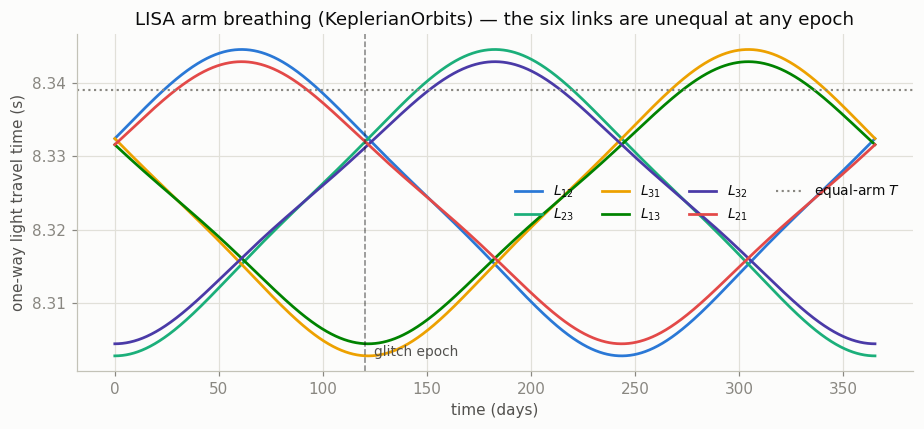

In [3]:
# Arm breathing over one year, with the chosen glitch epoch marked
t_yr = np.linspace(0.0, 365.25 * 86400.0, 2000)
ltt_yr = link_ltt(t_yr, orbits)                # (2000, 6)

fig, ax = plt.subplots(figsize=(8.5, 4))
for k, lk in enumerate(LINKS):
    ax.plot(t_yr / 86400.0, ltt_yr[:, k], color=PALETTE6[k], label=f"$L_{{{lk}}}$")
ax.axhline(T_ARM_s, color="#898781", ls=":", lw=1.4, label="equal-arm $T$")
ax.axvline((T_EPOCH + T0_TRUE) / 86400.0, color="#0b0b0b", ls="--", lw=1.0, alpha=0.5)
ax.annotate("glitch epoch", xy=((T_EPOCH + T0_TRUE) / 86400.0, ax.get_ylim()[0]),
            xytext=(6, 10), textcoords="offset points", color="#52514e", fontsize=9)
ax.set_xlabel("time (days)")
ax.set_ylabel("one-way light travel time (s)")
ax.set_title("LISA arm breathing (KeplerianOrbits) — the six links are unequal at any epoch")
ax.legend(ncols=4, fontsize=9)
plt.tight_layout()
plt.show()

## 2. Reduction check: unequal-arm code with equal delays

Feeding `ltt = T_ARM_s * ones(6)` into the unequal-arm functions must reproduce the
existing equal-arm functions **exactly** (same algebra, degenerate delays). This validates
the new implementation against the code already tested in the other notebooks.

In [4]:
n = int(T_OBS_s / DT_s)
t = jnp.arange(n) * DT_s
f = freq_grid(T_OBS_s, DT_s)

print(f"{'':14s}{'max |Δ FD|':>14s}{'max |Δ TD|':>14s}{'FD scale':>14s}")
for tdi in (1, 2):
    dF = float(jnp.max(jnp.abs(clean_signal_f_unequal(params, f, ltt_eq, tdi=tdi)
                               - clean_signal_f(params, f, tdi=tdi))))
    dT = float(jnp.max(jnp.abs(clean_signal_t_unequal(params, t, ltt_eq, tdi=tdi)
                               - clean_signal_t(params, t, tdi=tdi))))
    scale = float(jnp.max(jnp.abs(clean_signal_f(params, f, tdi=tdi))))
    print(f"TDI-{tdi}:{'':8s}{dF:14.3e}{dT:14.3e}{scale:14.3e}")
print("\n→ zero to machine precision: the unequal-arm code contains the equal-arm model as a special case.")

                  max |Δ FD|    max |Δ TD|      FD scale


TDI-1:             9.784e-32     2.407e-35     2.998e-18


TDI-2:             1.418e-31     2.407e-35     4.895e-18

→ zero to machine precision: the unequal-arm code contains the equal-arm model as a special case.


## 3. Frequency domain: TDI together and their difference

Analytic frequency-domain signals, equal-arm vs numerical orbits, for the A, E, T channels.
Top row: $|\tilde h(f)|$ of both models; bottom row: $|\tilde h_{\rm eq} - \tilde h_{\rm orb}|$.

The two spectra have nearly identical envelopes — the difference lives in the **positions of
the transfer-function nulls** ($f = k/(L_{\rm round\,trip})$) and in the phases, so the
residual rises steeply with frequency and peaks near the nulls.

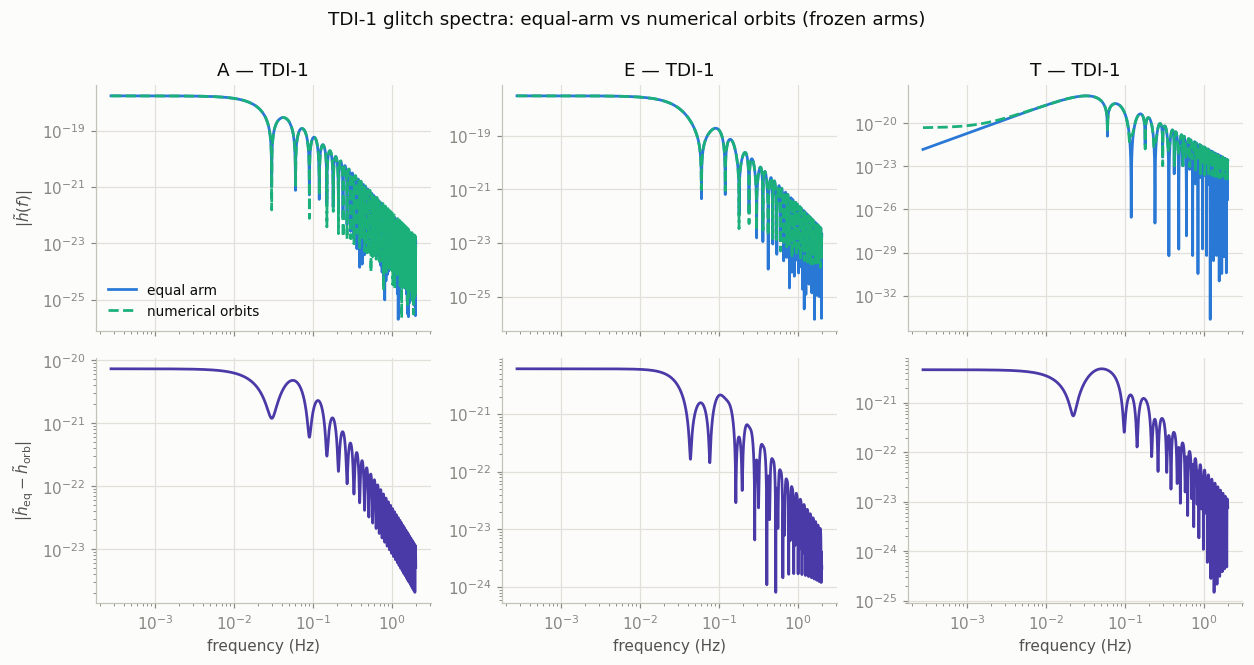

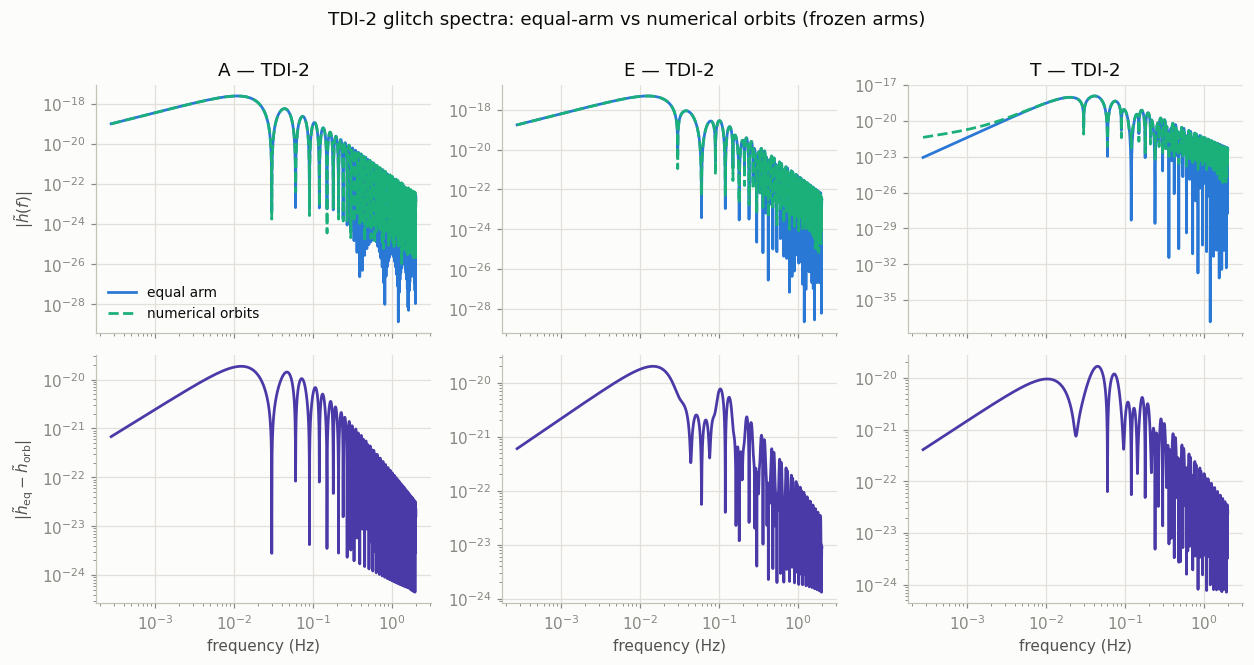

In [5]:
h_f = {}   # h_f[tdi] = (equal, orbit) frequency-domain signals, (F, 3) each
for tdi in (1, 2):
    h_f[tdi] = (clean_signal_f(params, f, tdi=tdi),
                clean_signal_f_unequal(params, f, ltt, tdi=tdi))

fsl = slice(1, None)  # skip DC

for tdi in (1, 2):
    heq, horb = h_f[tdi]
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 6), sharex=True)
    for c in range(3):
        ax = axes[0, c]
        ax.loglog(f[fsl], jnp.abs(heq[fsl, c]), color=COL_EQ, label="equal arm")
        ax.loglog(f[fsl], jnp.abs(horb[fsl, c]), color=COL_ORB, ls="--", label="numerical orbits")
        ax.set_title(f"{CHANNELS[c]} — TDI-{tdi}")
        if c == 0:
            ax.set_ylabel(r"$|\tilde h(f)|$")
            ax.legend(fontsize=9)
        axd = axes[1, c]
        axd.loglog(f[fsl], jnp.abs(heq[fsl, c] - horb[fsl, c]), color=COL_DIFF)
        axd.set_xlabel("frequency (Hz)")
        if c == 0:
            axd.set_ylabel(r"$|\tilde h_{\rm eq} - \tilde h_{\rm orb}|$")
    fig.suptitle(f"TDI-{tdi} glitch spectra: equal-arm vs numerical orbits (frozen arms)", y=1.0)
    plt.tight_layout()
    plt.show()

## 4. Time domain: TDI together and their difference

The time-domain waveform is a train of shapelet pulses at delays built from the arm round
trips. With realistic orbits the pulses shift by $\mathcal{O}(10\text{–}100)$ ms:

* pulses that **cancel exactly** in the equal-arm case (e.g. the $+D_{12}D_{21}$ / $-D_{13}D_{31}$
  pair in $X_1$) survive as short transients with unequal arms;
* every surviving pulse edge is displaced, so the difference is largest at the pulse onsets.

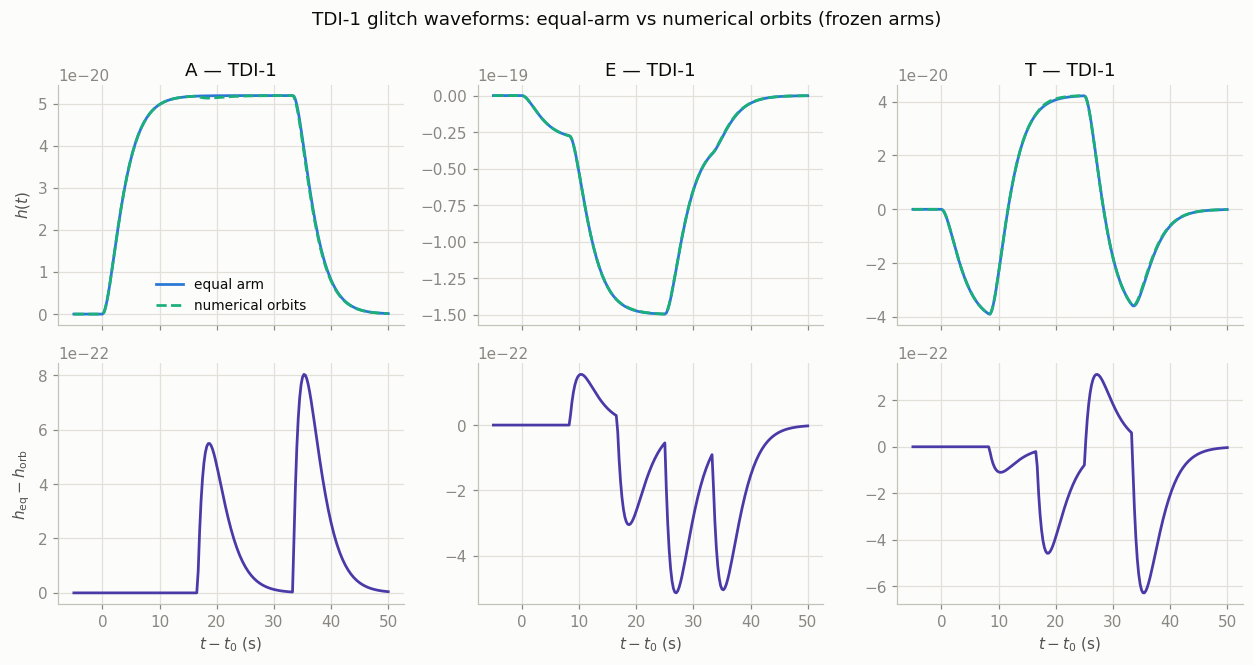

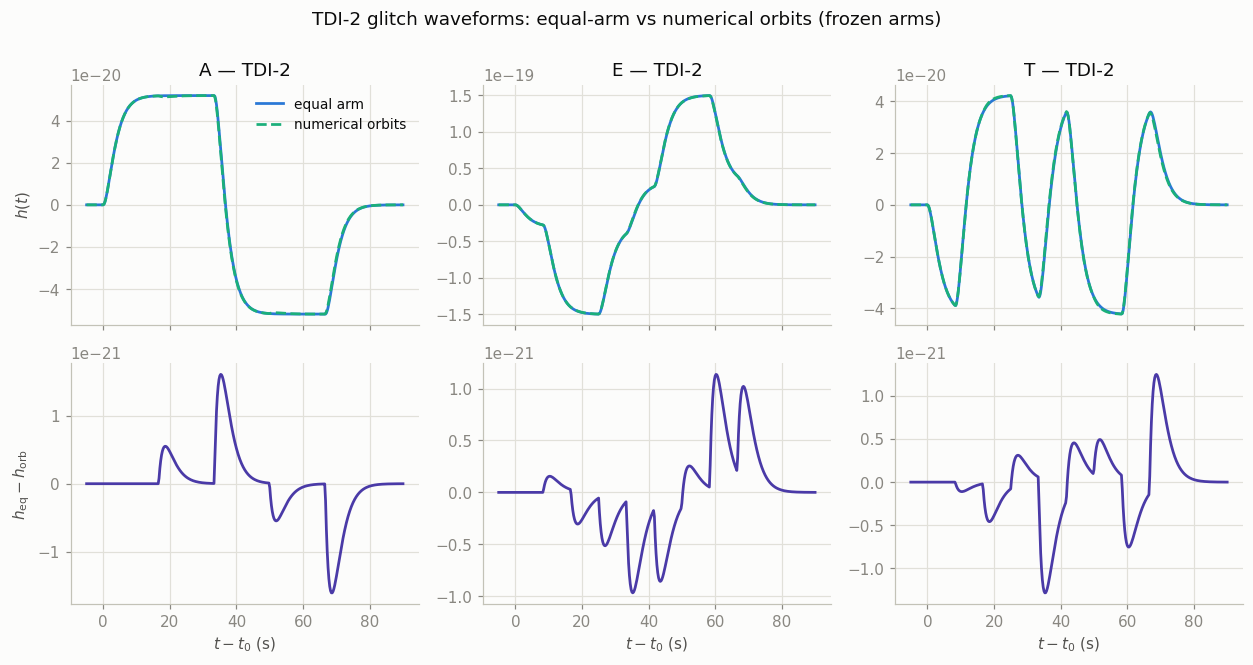

In [6]:
h_t = {}   # h_t[tdi] = (equal, orbit) time-domain signals, (N, 3) each
for tdi in (1, 2):
    h_t[tdi] = (clean_signal_t(params, t, tdi=tdi),
                clean_signal_t_unequal(params, t, ltt, tdi=tdi))

for tdi in (1, 2):
    heq, horb = h_t[tdi]
    zoom = (t >= T0_TRUE - 5.0) & (t <= T0_TRUE + (50.0 if tdi == 1 else 90.0))
    tz = t[zoom] - T0_TRUE
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 6), sharex=True)
    for c in range(3):
        ax = axes[0, c]
        ax.plot(tz, heq[zoom, c], color=COL_EQ, label="equal arm")
        ax.plot(tz, horb[zoom, c], color=COL_ORB, ls="--", label="numerical orbits")
        ax.set_title(f"{CHANNELS[c]} — TDI-{tdi}")
        if c == 0:
            ax.set_ylabel(r"$h(t)$")
            ax.legend(fontsize=9)
        axd = axes[1, c]
        axd.plot(tz, heq[zoom, c] - horb[zoom, c], color=COL_DIFF)
        axd.set_xlabel(r"$t - t_0$ (s)")
        if c == 0:
            axd.set_ylabel(r"$h_{\rm eq} - h_{\rm orb}$")
    fig.suptitle(f"TDI-{tdi} glitch waveforms: equal-arm vs numerical orbits (frozen arms)", y=1.0)
    plt.tight_layout()
    plt.show()

## 5. Internal consistency of the new functions

Two cross-checks, mirroring the ones that already exist for the equal-arm code:

1. **Time ↔ frequency**: the FFT of the analytic time-domain waveform must match the
   analytic frequency-domain waveform (up to spectral leakage from the finite window,
   the same $\sim 10^{-6}$ relative level as for the equal-arm code).
2. **Transfer-function route**: `compute_TDI_unequal(raw_glitch_f(...))` must equal
   `clean_signal_f_unequal(...)` to machine precision.

In [7]:
raw_fd = raw_glitch_f(params, f)
print(f"{'':14s}{'FD vs FFT(TD), rel.':>22s}{'compute_TDI_unequal vs clean_signal_f_unequal':>48s}")
for tdi in (1, 2):
    heq_f, horb_f = h_f[tdi]
    horb_t = h_t[tdi][1]
    horb_f_num = jnp.fft.rfft(horb_t, axis=0) * DT_s
    rel = float(jnp.max(jnp.abs(horb_f[fsl] - horb_f_num[fsl]))
                / jnp.max(jnp.abs(horb_f[fsl])))
    d_tf = float(jnp.max(jnp.abs(horb_f - compute_TDI_unequal(raw_fd, f, ltt, tdi=tdi))))
    print(f"TDI-{tdi}:{'':8s}{rel:22.3e}{d_tf:48.3e}")

                 FD vs FFT(TD), rel.   compute_TDI_unequal vs clean_signal_f_unequal


TDI-1:                     1.104e-05                                       0.000e+00
TDI-2:                     1.170e-05                                       0.000e+00


## 6. Does the equal-arm approximation matter? PSD-weighted comparison (TDI-1)

We quantify the model difference with the noise-weighted inner product (PSD from
`noise.py`):

* $\mathrm{SNR}(\delta h)$ with $\delta h = h_{\rm eq} - h_{\rm orb}$ — the residual left in
  the data if a glitch generated with realistic arms is subtracted with the
  equal-arm template at the true parameters;
* the **mismatch** $1 - \langle h_{\rm eq} | h_{\rm orb} \rangle /
  \sqrt{\langle h_{\rm eq}|h_{\rm eq}\rangle\langle h_{\rm orb}|h_{\rm orb}\rangle}$.

A rule of thumb: the approximation starts to bias parameter estimation once
$\mathrm{SNR}(\delta h) \gtrsim 1$, i.e. for glitch SNRs above
$\sim \mathrm{SNR}(h) / \mathrm{SNR}(\delta h)$ (per unit SNR the residual scales linearly).

**Why TDI-1 here?** The analytic *equal-arm* TDI-2 PSD,
$S_2(f) = 4\sin^2(4\pi f T)\,S_1(f)$, has exact nulls at $f = k/(4T)$ where the equal-arm
signal also vanishes. With unequal arms the signal nulls move to
$f = k/(L_{12}+L_{21}+L_{13}+L_{31}) \neq k/(4T)$ and no longer coincide with the PSD nulls,
so weighting an unequal-arm signal by the equal-arm TDI-2 PSD spuriously blows up near
every null. A consistent TDI-2 analysis needs the **unequal-arm noise PSD** built from the
same frozen delays — a natural next step for `noise.py`. Since TDI-2 is (in this
approximation) a common invertible filter applied to both signal and noise, SNRs and
mismatches computed in TDI-1 carry over to TDI-2.

In [8]:
psd1 = noise.psd_tdi1_array(jnp.where(f > 0, f, f[1]))   # (F, 3); guard f=0
heq_f, horb_f = h_f[1]
snr_eq   = float(snr(heq_f,  psd1))
snr_orb  = float(snr(horb_f, psd1))
snr_diff = float(snr(heq_f - horb_f, psd1))
overlap  = float(inner_product(heq_f, horb_f, psd1)) / (snr_eq * snr_orb)
print(f"TDI-1:  SNR(h_eq) = {snr_eq:8.2f}   SNR(h_orb) = {snr_orb:8.2f}   "
      f"SNR(h_eq - h_orb) = {snr_diff:8.2f}")
print(f"        overlap = {overlap:.6f}   mismatch = {1.0 - overlap:.3e}   "
      f"residual/signal = {snr_diff / snr_orb:.3f}")
print(f"\n→ the equal-arm approximation leaves ~{100*snr_diff/snr_orb:.0f}% of the glitch SNR "
      f"as residual: negligible for weak glitches,\n  but it biases loud ones "
      f"(SNR ≳ {snr_orb/snr_diff:.0f} in this normalization).")

TDI-1:  SNR(h_eq) =  5398.81   SNR(h_orb) =  5397.08   SNR(h_eq - h_orb) =   156.29
        overlap = 0.999581   mismatch = 4.191e-04   residual/signal = 0.029

→ the equal-arm approximation leaves ~3% of the glitch SNR as residual: negligible for weak glitches,
  but it biases loud ones (SNR ≳ 35 in this normalization).


## 7. Likelihood: fitting realistic data with each template

Finally, the intended use in inference: synthetic **noise-free data generated with the
numerical-orbit model** (TDI-1, for the PSD reason above), analysed with

* the new unequal-arm likelihood (`make_log_likelihood_unequal`) — should peak at the truth
  with $\log L = 0$;
* the old equal-arm likelihood (`make_log_likelihood`) — biased: its peak is displaced in
  $t_0$ and sits below zero by the residual power.

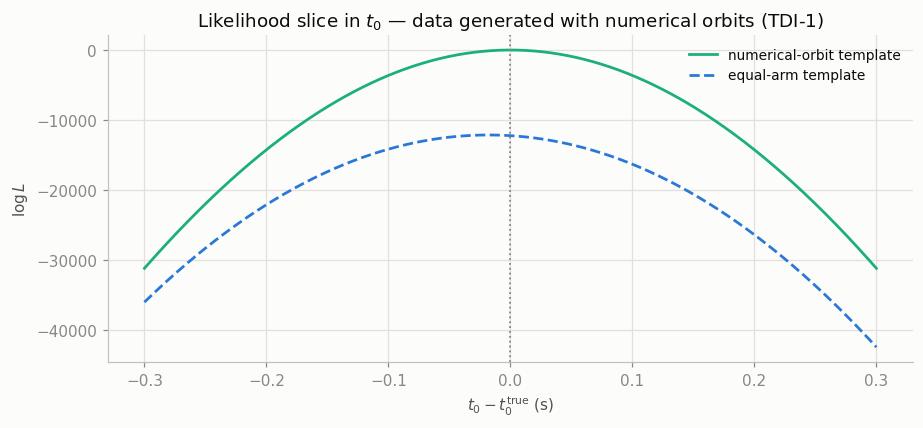

numerical-orbit template:  logL(truth) = -3.429e-24  (exact match)
equal-arm template:        peak at t0 offset = -18.0 ms, peak logL = -12117.22


In [9]:
tdi = 1
psd = noise.psd_tdi1_array(jnp.where(f > 0, f, f[1]))
data_fd = clean_signal_f_unequal(params, f, ltt, tdi=tdi)   # noise-free realistic data

logL_orb = make_log_likelihood_unequal(data_fd, psd, f, ltt, tdi=tdi)
logL_eq  = make_log_likelihood(data_fd, psd, f, tdi=tdi)

dt0 = jnp.linspace(-0.3, 0.3, 601)
scan = jax.vmap(lambda d: jnp.stack([logL_orb(params + jnp.array([d, 0.0, 0.0])),
                                     logL_eq(params + jnp.array([d, 0.0, 0.0]))]))(dt0)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(dt0, scan[:, 0], color=COL_ORB, label="numerical-orbit template")
ax.plot(dt0, scan[:, 1], color=COL_EQ, ls="--", label="equal-arm template")
ax.axvline(0.0, color="#898781", ls=":", lw=1.2)
ax.set_xlabel(r"$t_0 - t_0^{\rm true}$ (s)")
ax.set_ylabel(r"$\log L$")
ax.set_title("Likelihood slice in $t_0$ — data generated with numerical orbits (TDI-1)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

i_eq = int(jnp.argmax(scan[:, 1]))
print(f"numerical-orbit template:  logL(truth) = {float(logL_orb(params)):.3e}  (exact match)")
print(f"equal-arm template:        peak at t0 offset = {float(dt0[i_eq])*1e3:+.1f} ms, "
      f"peak logL = {float(scan[i_eq, 1]):.2f}")

## 8. Glitch inference with `jexplore` — the bias from assuming equal arms

The point of the upgrade: if the data are produced by the **real, non-equal-arm** instrument
but analysed with the **equal-arm** template, parameter estimation is *biased*. Here we show it
directly with the affine-invariant ensemble sampler
[`jexplore`](https://gitlab.in2p3.fr/lisa-apc/jexplore) (stretch move, Goodman & Weare 2010 —
the same sampler used in `lisa.ipynb`).

**Set-up**
- **Injection**: a single glitch simulated with the numerical orbits (`clean_signal_f_unequal`,
  TDI-1), amplitude chosen for a loud $\mathrm{SNR}\approx 2000$ — glitches this loud are common
  in the LPF population, and the systematic bias grows *linearly* with SNR, so a loud event makes
  it visible against the (shrinking) statistical width.
- **Zero-noise (Asimov) injection**: no noise is added, so the correct-template posterior centres
  exactly on the truth and *any* offset of the equal-arm posterior is pure **systematic model
  bias**, not a noise fluctuation.
- **TDI-1** throughout (its PSD has no nulls — see §6/§7).
- We sample in $[t_0, \log\Delta v, \log\tau]$ (flat priors there), exactly as in `lisa.ipynb`.
- Both chains are launched from the **same** compact ball around the injected truth. This is a
  convergence device, not a constraint: identical for both templates, so it cannot favour a
  direction. The equal-arm chain then *migrates away* from the truth to its own mode — which is
  precisely the bias we want to expose. (The `lisa.ipynb` prior-start burn-in would also work but
  wastes thousands of iterations migrating onto such a narrow high-SNR mode.)

In [10]:
import jax.random as jr
from jaxglitches import fisher_matrix_unequal
from jaxglitches.priors import to_physical, to_sampling, log_prior_sampling
from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch
from jexplore.backends import DefaultBackend

# ── Injection: loud glitch, numerical orbits, TDI-1, zero noise (Asimov) ──────
SNR_INJ = 2000.0
psd_mcmc = noise.psd_tdi1_array(jnp.where(f > 0, f, f[1]))          # (F, 3)

# scale Deltav to hit the target SNR (SNR ∝ Deltav)
snr_ref = float(snr(clean_signal_f_unequal(jnp.array([T0_TRUE, 1e-13, TAU_TRUE]),
                                           f, ltt, tdi=1), psd_mcmc))
DV_INJ = 1e-13 * SNR_INJ / snr_ref
params_inj = jnp.array([T0_TRUE, DV_INJ, TAU_TRUE])
xi_true = to_sampling(params_inj)

data_inj = clean_signal_f_unequal(params_inj, f, ltt, tdi=1)        # noise-free realistic data
print(f"injected glitch : t0={T0_TRUE:.0f} s, Deltav={DV_INJ:.3e} m/s, tau={TAU_TRUE:.1f} s")
print(f"injected SNR (TDI-1, numerical orbits) = {float(snr(data_inj, psd_mcmc)):.0f}")

# ── Two likelihoods on the SAME data: correct (unequal) vs equal-arm ──────────
log_L_orb = make_log_likelihood_unequal(data_inj, psd_mcmc, f, ltt, tdi=1)
log_L_eq  = make_log_likelihood(data_inj, psd_mcmc, f, T=T_ARM_s, tdi=1)
loglik_orb = jax.jit(lambda xi: log_L_orb(to_physical(xi)))
loglik_eq  = jax.jit(lambda xi: log_L_eq(to_physical(xi)))
print(f"logL_orb(truth) = {float(loglik_orb(xi_true)):+.3e}  (0 by construction)")
print(f"logL_eq (truth) = {float(loglik_eq(xi_true)):+.3e}  (< 0: equal-arm cannot fit realistic data)")

# ── Fisher 1σ (correct model) — sets the init-ball width and the bias units ───
G_phys = fisher_matrix_unequal(params_inj, f, psd_mcmc, ltt, tdi=1)
Jc = jnp.array([[1., 0., 0.], [0., float(DV_INJ), 0.], [0., 0., float(TAU_TRUE)]])
C_fish = jnp.linalg.inv(Jc.T @ G_phys @ Jc)            # covariance in [t0, logDv, logTau]
sig_fish = jnp.sqrt(jnp.diag(C_fish))
print(f"Fisher 1σ  [t0, logDv, logTau] = {np.array(sig_fish)}")

injected glitch : t0=1800 s, Deltav=8.153e-12 m/s, tau=2.0 s
injected SNR (TDI-1, numerical orbits) = 2000


logL_orb(truth) = -4.673e-24  (0 by construction)


logL_eq (truth) = -1.677e+03  (< 0: equal-arm cannot fit realistic data)


Fisher 1σ  [t0, logDv, logTau] = [0.00538248 0.00054564 0.00177103]


In [11]:
# ── Affine-invariant ensemble sampler (stretch move), compact-ball launch ─────
N_WALKERS = 16      # ensemble size (even, ≥ 2×dim)
N_BURN    = 400     # short settling (discarded) — the launch ball is already near the mode
N_SAMP    = 3000    # production iterations per walker  → 16×3000 = 48k samples

def run_ensemble(loglik_fn, seed):
    # Launch N_WALKERS from a compact Gaussian ball (5 Fisher-sigma) around the
    # injected truth in sampling coords, then run the stretch move. Identical launch
    # for both templates. Returns the flat production chain (N_WALKERS x N_SAMP, 3).
    sampling = SamplingMH(nwalker=N_WALKERS, temps=jnp.array([1.0]),
                          loglik=loglik_fn, logprior=jax.jit(log_prior_sampling), dim=3)
    steps = Steps([{Stretch(permute=True).builder: 1.0}])
    p0 = xi_true + 5.0 * sig_fish * jr.normal(jr.PRNGKey(seed), (N_WALKERS, 3))
    back = DefaultBackend(burn=N_BURN, inmem_epochs=1)
    JaxSampler(sampling, steps, back).run(
        EpochMH({"p": p0}), niters=N_BURN + N_SAMP, nepoch=1, seed=seed + 1)
    return jnp.array(back.get_samples()["p"].transpose(0, 2, 1).reshape(-1, 3))

import time
t0 = time.time()
print("sampling with the numerical-orbit template ...")
chain_orb = run_ensemble(loglik_orb, seed=1)
print("sampling with the equal-arm template ...")
chain_eq  = run_ensemble(loglik_eq,  seed=2)
print(f"done in {time.time() - t0:.0f} s  —  {chain_orb.shape[0]:,} samples each")

phys_orb = jax.vmap(to_physical)(chain_orb)   # (N, 3) = [t0, Deltav, tau]
phys_eq  = jax.vmap(to_physical)(chain_eq)

# convergence check: MCMC width vs Fisher (correct-model chain should match ~1)
sig_mcmc = jnp.std(chain_orb, axis=0)
print("convergence (numerical template): σ_MCMC / σ_Fisher =",
      np.array(jnp.round(sig_mcmc / sig_fish, 2)))

sampling with the numerical-orbit template ...


sampling with the equal-arm template ...


done in 15 s  —  48,000 samples each


convergence (numerical template): σ_MCMC / σ_Fisher = [1.02 0.98 0.99]


In [12]:
# ── Bias table: where each posterior sits, in units of the Fisher 1σ ──────────
labels = ["t0 (s)", "Deltav (m/s)", "tau (s)"]
print(f"{'parameter':14s}{'truth':>15s}{'numerical med':>17s}{'equal-arm med':>17s}"
      f"{'num bias':>11s}{'eq bias':>10s}")
print("-" * 84)
for i, lab in enumerate(labels):
    tv = float(params_inj[i]); mo = float(jnp.median(phys_orb[:, i])); me = float(jnp.median(phys_eq[:, i]))
    # bias in Fisher-σ: linear for t0, log-space for Deltav & tau (that's the sampling coord)
    bo = (mo - tv) / sig_fish[0] if i == 0 else (jnp.log(mo) - jnp.log(tv)) / sig_fish[i]
    be = (me - tv) / sig_fish[0] if i == 0 else (jnp.log(me) - jnp.log(tv)) / sig_fish[i]
    print(f"{lab:14s}{tv:15.4e}{mo:17.4e}{me:17.4e}{float(bo):>+10.2f}σ{float(be):>+9.2f}σ")
print("\n→ the numerical-orbit template recovers the truth (< 0.1σ); the equal-arm template is")
print("  offset by ~1–2σ per parameter — a systematic bias that scales linearly with SNR.")

parameter               truth    numerical med    equal-arm med   num bias   eq bias
------------------------------------------------------------------------------------
t0 (s)             1.8000e+03       1.8000e+03       1.8000e+03     +0.05σ    -2.28σ
Deltav (m/s)       8.1526e-12       8.1521e-12       8.1445e-12     -0.10σ    -1.82σ
tau (s)            2.0000e+00       1.9998e+00       1.9962e+00     -0.07σ    -1.07σ

→ the numerical-orbit template recovers the truth (< 0.1σ); the equal-arm template is
  offset by ~1–2σ per parameter — a systematic bias that scales linearly with SNR.


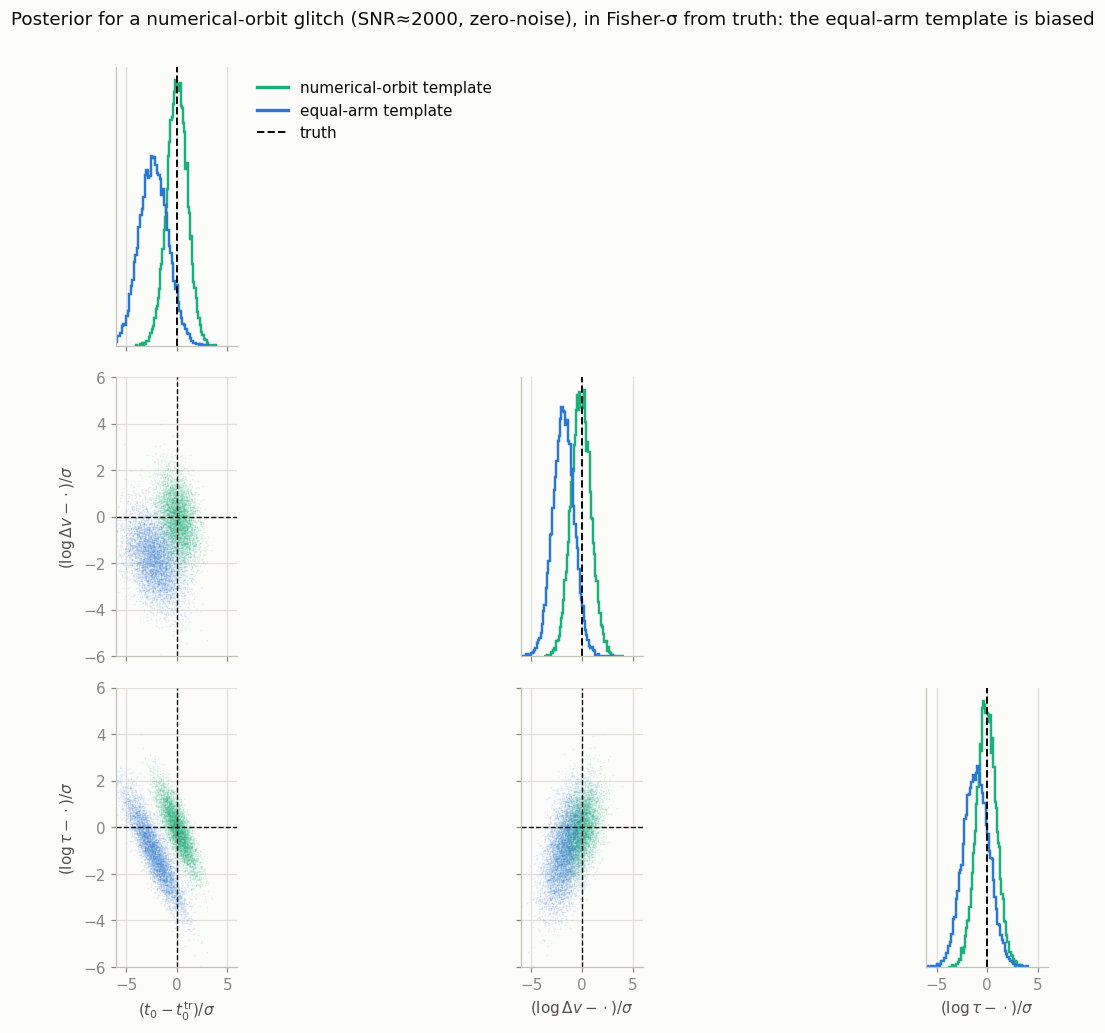

In [13]:
# ── Corner plot: posteriors in "σ from truth" (sampling coords, Fisher-scaled) ─
# Standardised coordinate  z_i = (xi_i - xi_true_i) / sigma_Fisher_i, with
# xi = [t0, logDeltav, logTau]. Truth sits at 0; the numerical-orbit posterior is a
# unit blob at 0, and the equal-arm posterior's offset is its bias *in sigma* — read
# straight off the axes. (Plotting raw physical values instead forces matplotlib into
# offset notation like "+1.799e3" that collides with the labels.)
z_orb = (chain_orb - xi_true) / sig_fish     # (N, 3)
z_eq  = (chain_eq  - xi_true) / sig_fish

def corner_sigma(samples, colors, labels_leg, axis_labels, thin=8, lim=6.0):
    n = len(axis_labels)
    fig, axes = plt.subplots(n, n, figsize=(3.1 * n, 3.1 * n))
    fig.subplots_adjust(hspace=0.06, wspace=0.06)
    for r in range(n):
        for c in range(n):
            ax = axes[r, c]
            if c > r:
                ax.set_visible(False); continue
            if c == r:
                for s, clr in zip(samples, colors):
                    ax.hist(np.array(s[:, c]), bins=70, density=True, histtype="step",
                            color=clr, lw=1.6)
                ax.axvline(0.0, color="#0b0b0b", ls="--", lw=1.3)
                ax.set_yticks([]); ax.set_xlim(-lim, lim)
            else:
                for s, clr in zip(samples, colors):
                    ss = s[::thin]
                    ax.plot(np.array(ss[:, c]), np.array(ss[:, r]), ".", color=clr,
                            alpha=0.12, ms=2, mec="none")
                ax.axvline(0.0, color="#0b0b0b", ls="--", lw=0.9)
                ax.axhline(0.0, color="#0b0b0b", ls="--", lw=0.9)
                ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
            if r == n - 1: ax.set_xlabel(axis_labels[c], fontsize=10)
            else:          ax.set_xticklabels([])
            if c == 0 and r > 0: ax.set_ylabel(axis_labels[r], fontsize=10)
            else:                ax.set_yticklabels([])
    handles = [plt.Line2D([0], [0], color=cl, lw=2.2, label=lb)
               for lb, cl in zip(labels_leg, colors)]
    handles += [plt.Line2D([0], [0], color="#0b0b0b", lw=1.3, ls="--", label="truth")]
    axes[0, 0].legend(handles=handles, fontsize=10, loc="upper left",
                      bbox_to_anchor=(1.05, 1.0))
    return fig

fig = corner_sigma(
    [z_orb, z_eq],
    [COL_ORB, COL_EQ],
    ["numerical-orbit template", "equal-arm template"],
    [r"$(t_0-t_0^{\rm tr})/\sigma$", r"$(\log\Delta v-\cdot)/\sigma$",
     r"$(\log\tau-\cdot)/\sigma$"])
fig.suptitle(f"Posterior for a numerical-orbit glitch (SNR≈{SNR_INJ:.0f}, zero-noise), "
             "in Fisher-σ from truth: the equal-arm template is biased", y=1.005, fontsize=12)
plt.tight_layout()
plt.show()

## Summary

* `orbits.py` wraps `lisaorbits` and freezes the six per-link light travel times at the
  glitch epoch (`link_ltt`), justified by the slow arm breathing versus glitch durations.
* `data.py` gains `clean_signal_f_unequal`, `clean_signal_t_unequal` and
  `compute_TDI_unequal` — exact analytic unequal-arm TDI-1/TDI-2 responses in both domains,
  reducing to the equal-arm functions at machine precision when all $L_{ij} = T$.
* `likelihood.py` gains `make_log_likelihood_unequal` and `fisher_matrix_unequal`.
* Time and frequency domains agree at the spectral-leakage level ($\sim 10^{-5}$ relative),
  exactly as for the equal-arm code.
* The equal-arm approximation leaves a residual of $\sim 3\%$ of the glitch SNR
  (mismatch $\sim 4\times10^{-4}$) and a $t_0$ bias of tens of ms — negligible for weak
  glitches, but worth the (free) upgrade for loud ones and for producing realistic TDI data.
* **§8 — inference (`jexplore`)**: analysing a numerical-orbit glitch (SNR $\approx 2000$,
  zero-noise) with the correct unequal-arm template recovers the truth to $< 0.1\sigma$, while
  the equal-arm template is biased by $\sim 1$–$2\sigma$ per parameter — a systematic error
  that grows linearly with SNR, so it dominates for loud glitches.
* **Caveat / next step**: the analytic PSDs in `noise.py` are equal-arm. For TDI-2 their
  nulls at $f = k/(4T)$ no longer align with the unequal-arm signal nulls, so a consistent
  unequal-arm TDI-2 likelihood needs the unequal-arm noise PSD built from the same frozen
  delays.